Data Cleaning and Preprocessing

1. **Preprocessing:** Load the raw CICFlowMeter CSV into `df`, remove the `Timestamp` column (`cols_to_drop`) since it is not useful for general attack-pattern learning, replace `±inf` values with `NaN`, and drop rows with missing values.

2. **Label Encoding:** Convert `Label` into binary form: `Benign → 0` and any attack class → `1`.

3. **Quick Validation:** Print the cleaned dataset shape and class distribution to confirm data quality and class balance before modeling.

In [ ]:
import pandas as pd
import numpy as np

# 1. Load the dataset
raw_data_path = "../data/raw/14-02-2018.csv"
df = pd.read_csv(raw_data_path)

# 2. Drop unnecessary features
# Timestamp is not useful for general attack patterns
cols_to_drop = ['Timestamp'] 
df = df.drop(columns=cols_to_drop)

# 3. Handle infinite and null values
# Network flow calculations often result in division by zero (Inf)
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

# 4. Binary Label Encoding
# Mapping: Benign -> 0, Any Attack -> 1
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'Benign' else 1)

print(f"Cleaned dataset shape: {df.shape}")
print(f"Target distribution:\n{df['Label'].value_counts()}")

Cleaned dataset shape: (1044751, 79)
Target distribution:
Label
0    663808
1    380943
Name: count, dtype: int64


Training Baseline Model

4. **Feature/Target Split:** Create `X` with all columns except `Label`, and `y` with only `Label` (binary target: benign vs attack).

5. **Train/Test Partition:** Split data into training (80%) and testing (20%) sets using `train_test_split(..., random_state=42)` for reproducible results.

6. **Model Training:** Initialize a `RandomForestClassifier` with `n_estimators=50`, `max_depth=10`, and `n_jobs=-1`, then fit it on `X_train` and `y_train`.

7. **Evaluation:** Predict on `X_test` and print `classification_report` to summarize precision, recall, F1-score, and support for each class.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Feature/Target separation
X = df.drop('Label', axis=1)
y = df['Label']

# 2. Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Model Initialization and Training
# Using n_jobs=-1 to use all CPU cores
clf = RandomForestClassifier(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
clf.fit(X_train, y_train)

# 4. Model Evaluation
y_pred = clf.predict(X_test)
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    132745
           1       1.00      1.00      1.00     76206

    accuracy                           1.00    208951
   macro avg       1.00      1.00      1.00    208951
weighted avg       1.00      1.00      1.00    208951



Feature Importance Analysis

8. **Importance Extraction:** Use the trained `RandomForestClassifier` (`clf`) to read `feature_importances_` and pair each score with its corresponding feature name from `X.columns`.

9. **Top Feature Selection:** Convert importances into a pandas `Series`, select the 10 most important features with `nlargest(10)`, and sort them in ascending order for cleaner horizontal plotting.

10. **Plotting:** Create a horizontal bar chart (`barh`) with Matplotlib to visualize the top contributors, then add title and x-axis label (`Gini Importance`) for interpretability.

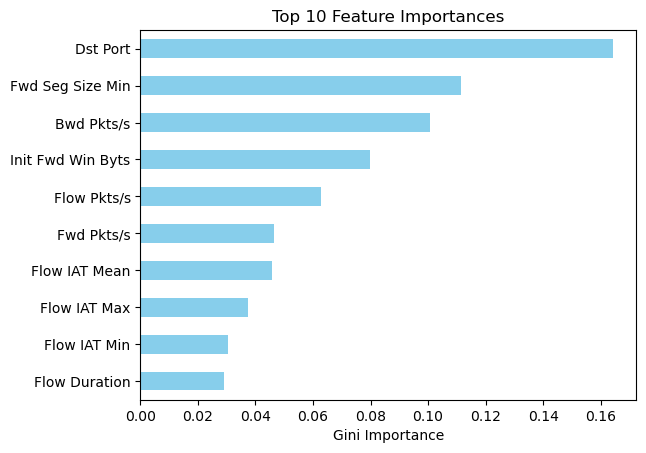

In [4]:
import matplotlib.pyplot as plt

# Extract and plot the top 10 features
importances = pd.Series(clf.feature_importances_, index=X.columns)
importances.nlargest(10).sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.title("Top 10 Feature Importances")
plt.xlabel("Gini Importance")
plt.show()

Single Most Important Feature Test

11. **Single-Feature Validation:** Train a new model using only the most important feature to check whether performance remains almost unchanged, which would suggest the full model relies heavily on that single variable.

In [5]:
# Identify the top feature from the previously trained full model
most_important_feature = importances.idxmax()
print(f"Most important feature: {most_important_feature}")

# Train/test using only that single feature
X_single = X[[most_important_feature]]
X_train_single, X_test_single, y_train_single, y_test_single = train_test_split(
    X_single, y, test_size=0.2, random_state=42
)

clf_single = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    n_jobs=-1,
    random_state=42
)
clf_single.fit(X_train_single, y_train_single)

y_pred_single = clf_single.predict(X_test_single)
print("\n--- Classification Report (Single Most Important Feature) ---")
print(classification_report(y_test_single, y_pred_single))

Most important feature: Dst Port

--- Classification Report (Single Most Important Feature) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    132745
           1       1.00      1.00      1.00     76206

    accuracy                           1.00    208951
   macro avg       1.00      1.00      1.00    208951
weighted avg       1.00      1.00      1.00    208951



Leakage Check: Remove Top Feature

12. **Leakage Probe (without Dst Port):** Retrain the model after removing the dominant feature (`Dst Port`) to verify whether performance drops significantly. A strong drop indicates the model depended heavily on that feature.

In [8]:
# Retrain without the dominant feature to test potential leakage dependence
feature_to_remove = "Dst Port"

if feature_to_remove not in X.columns:
    raise ValueError(f"Feature '{feature_to_remove}' not found in X columns.")

X_without_top = X.drop(columns=[feature_to_remove])
X_train_wo, X_test_wo, y_train_wo, y_test_wo = train_test_split(
    X_without_top, y, test_size=0.2, random_state=42
)

clf_wo_top = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    n_jobs=-1,
    random_state=42
)
clf_wo_top.fit(X_train_wo, y_train_wo)

y_pred_wo = clf_wo_top.predict(X_test_wo)
print(f"\n--- Classification Report (Without '{feature_to_remove}') ---")
print(classification_report(y_test_wo, y_pred_wo))


--- Classification Report (Without 'Dst Port') ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    132745
           1       1.00      1.00      1.00     76206

    accuracy                           1.00    208951
   macro avg       1.00      1.00      1.00    208951
weighted avg       1.00      1.00      1.00    208951



Honest Analysis (Reduced Leakage Features)

13. **Leakage-Reduced Setup:** Build `df_honest` from the already preprocessed `df` and remove leakage-prone columns if they still exist (`Dst Port`, `Protocol`, `Timestamp`) without failing when one is already absent.

14. **Training and Evaluation:** Train a new `RandomForestClassifier` with the same split strategy and report metrics as `--- Honest Classification Report ---` for direct comparison.

15. **Behavioral Feature Importance:** Plot the top 10 importances from the leakage-reduced model to identify which non-leakage behavioral signals are driving predictions.

--- Honest Classification Report ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    132745
           1       1.00      1.00      1.00     76206

    accuracy                           1.00    208951
   macro avg       1.00      1.00      1.00    208951
weighted avg       1.00      1.00      1.00    208951



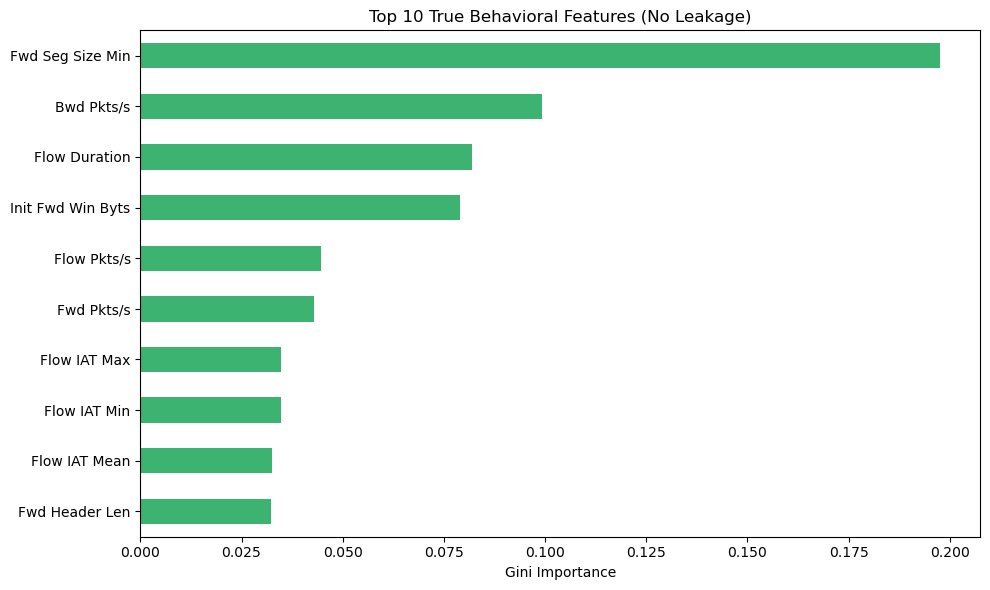

In [9]:
# Start from the already preprocessed dataset and remove leakage-prone features if present
leakage_features = ['Dst Port', 'Protocol', 'Timestamp']
present_leakage_features = [col for col in leakage_features if col in df.columns]

df_honest = df.drop(columns=present_leakage_features).copy()
df_honest = df_honest.replace([np.inf, -np.inf], np.nan)
df_honest = df_honest.dropna()

# Keep compatibility if Label is still text in some runs
if df_honest['Label'].dtype == 'object':
    df_honest['Label'] = df_honest['Label'].apply(lambda x: 0 if x == 'Benign' else 1)

X_honest = df_honest.drop('Label', axis=1)
y_honest = df_honest['Label']

X_train_honest, X_test_honest, y_train_honest, y_test_honest = train_test_split(
    X_honest, y_honest, test_size=0.2, random_state=42
)

clf_honest = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    n_jobs=-1,
    random_state=42
)
clf_honest.fit(X_train_honest, y_train_honest)

y_pred_honest = clf_honest.predict(X_test_honest)
print('--- Honest Classification Report ---')
print(classification_report(y_test_honest, y_pred_honest))

# Plot top behavioral features after removing leakage-prone columns
importances_honest = pd.Series(clf_honest.feature_importances_, index=X_honest.columns)
plt.figure(figsize=(10, 6))
importances_honest.nlargest(10).sort_values(ascending=True).plot(kind='barh', color='mediumseagreen')
plt.title('Top 10 True Behavioral Features (No Leakage)')
plt.xlabel('Gini Importance')
plt.tight_layout()
plt.show()